In [1]:
import pandas as pd
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt

In [4]:
from google.colab import files
import pandas as pd
upload = files.upload()
data = pd.read_csv("FEDFUNDS (1).csv")

Saving FEDFUNDS (1).csv to FEDFUNDS (1) (1).csv


In [6]:
from google.colab import files
import pandas as pd
upload = files.upload()
data = pd.read_csv("T10Y2Y (1).csv")

Saving T10Y2Y (1).csv to T10Y2Y (1) (1).csv


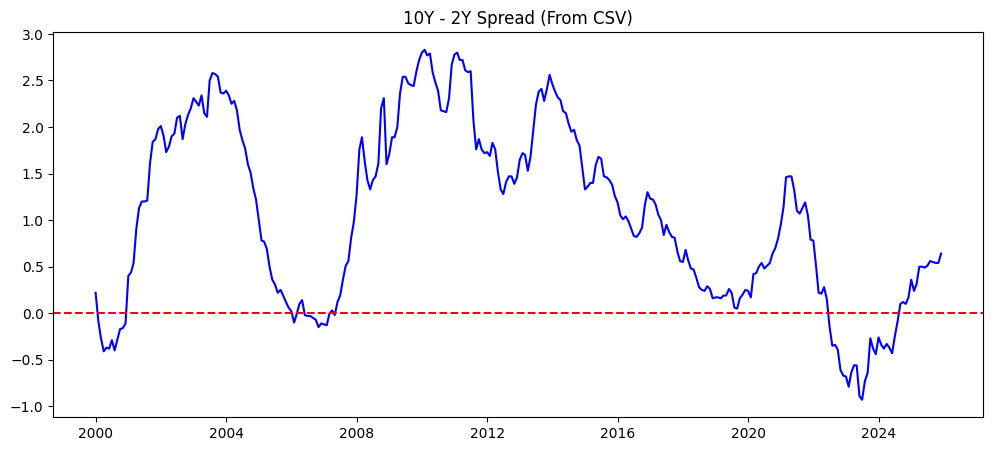

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/T10Y2Y (1).csv', parse_dates=['observation_date'], index_col='observation_date')

df = df[df['T10Y2Y'] != '.']
df['T10Y2Y'] = df['T10Y2Y'].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['T10Y2Y'], color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("10Y - 2Y Spread (From CSV)")
plt.show()

====== 2000年至今：處理缺失值前 (Null values before filling) ======
T10Y2Y      0
FEDFUNDS    0
dtype: int64
====== 2000年至今：處理缺失值後 (Null values after filling) ======
T10Y2Y      0
FEDFUNDS    0
dtype: int64

====== 2000年至今：Fed利率與美債利差相關性矩陣 ======
            T10Y2Y  FEDFUNDS
T10Y2Y    1.000000 -0.733609
FEDFUNDS -0.733609  1.000000

💡 統計洞察：在 2000 年至 2025 年間，兩者相關係數為 -0.73


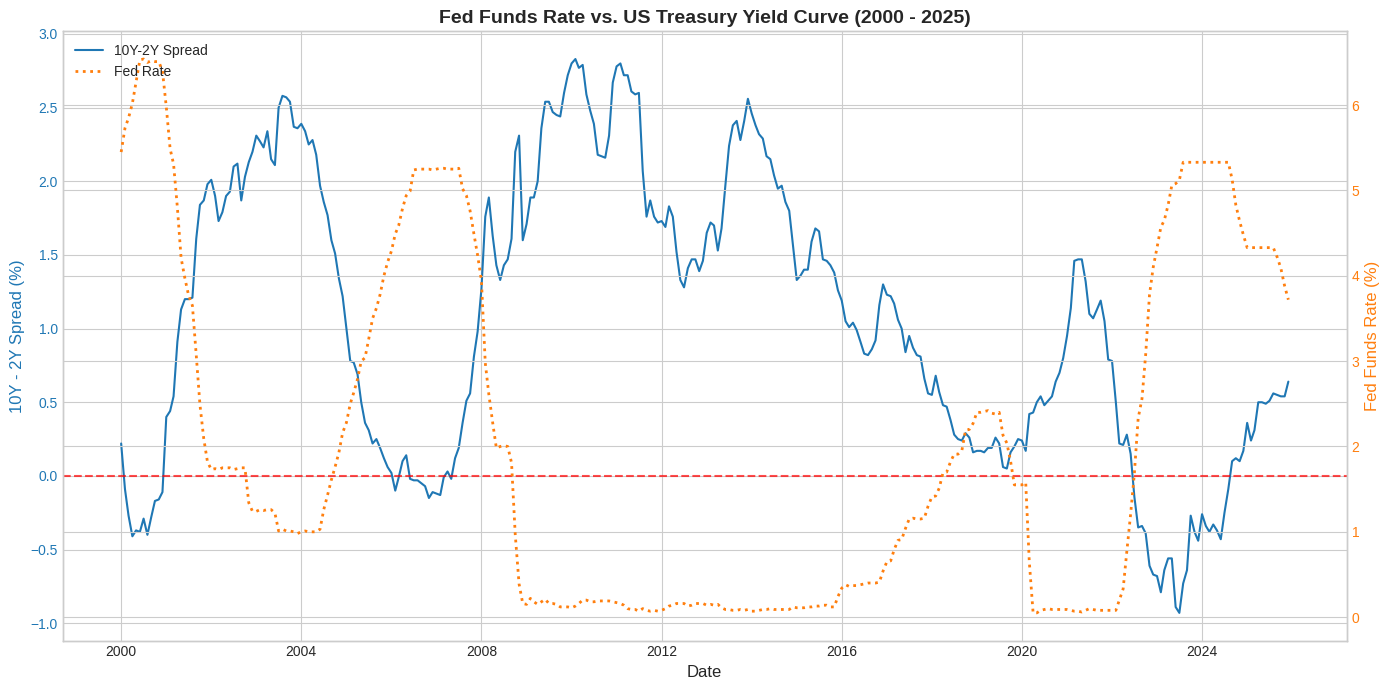

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' from the previous cell is the processed T10Y2Y spread data
df_spread = df.copy()

# Load FEDFUNDS data directly into df_fed
df_fed = pd.read_csv('/content/FEDFUNDS (1).csv', parse_dates=['observation_date'], index_col='observation_date')

df_fed = df_fed[df_fed['FEDFUNDS'] != '.']
df_fed['FEDFUNDS'] = df_fed['FEDFUNDS'].astype(float)

# Ensure indices are datetime objects and have the correct name for merging
df_spread.index = pd.to_datetime(df_spread.index)
df_fed.index = pd.to_datetime(df_fed.index)

# Perform the merge
df_macro = pd.merge(df_spread, df_fed[['FEDFUNDS']], left_index=True, right_index=True, how='inner')

# Change the filtering range to 2000-01-01 to 2025-12-31
df_macro_filtered = df_macro.loc['2000-01-01':'2025-12-31']

print("====== 2000年至今：處理缺失值前 (Null values before filling) ======")
print(df_macro_filtered.isnull().sum())

df_macro_filtered = df_macro_filtered.ffill().bfill()

print("====== 2000年至今：處理缺失值後 (Null values after filling) ======")
print(df_macro_filtered.isnull().sum())
print("===================================================\n")


matrix = df_macro_filtered.corr()

print("====== 2000年至今：Fed利率與美債利差相關性矩陣 ======")
print(matrix)
print("===================================================\n")

corr_value = matrix.loc['T10Y2Y', 'FEDFUNDS']
print(f"💡 統計洞察：在 2000 年至 2025 年間，兩者相關係數為 {corr_value:.2f}")

fig, ax1 = plt.subplots(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

color = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('10Y - 2Y Spread (%)', color=color, fontsize=12)
ax1.plot(df_macro_filtered.index, df_macro_filtered['T10Y2Y'], color=color, linewidth=1.5, label='10Y-2Y Spread')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Fed Funds Rate (%)', color=color, fontsize=12)
ax2.plot(df_macro_filtered.index, df_macro_filtered['FEDFUNDS'], color=color, linewidth=2, linestyle=':', label='Fed Rate')
ax2.tick_params(axis='y', labelcolor=color)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Update the plot title
plt.title('Fed Funds Rate vs. US Treasury Yield Curve (2000 - 2025)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()